#Pattern-Based Generator

In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import uuid

class PatternBasedGenerator:
    def __init__(self, start_date="2023-01-01", end_date="2023-12-31", seed=42):
        """Initialize the pattern-based generator with date range and random seed"""
        self.start_date = datetime.strptime(start_date, "%Y-%m-%d")
        self.end_date = datetime.strptime(end_date, "%Y-%m-%d")
        random.seed(seed)
        np.random.seed(seed)

        # Define entities for transactions
        self.entities = {
            "legitimate": [
                {"name": "LegitCorp A", "country": "LV", "risk": "LOW"},
                {"name": "EuroTrade B", "country": "DE", "risk": "LOW"},
                {"name": "Nordic Services", "country": "FI", "risk": "LOW"},
                {"name": "Baltic Imports", "country": "LT", "risk": "LOW"}
            ],
            "suspicious": [
                {"name": "Shell Corp X", "country": "CY", "risk": "HIGH"},
                {"name": "Offshore Holdings", "country": "VG", "risk": "HIGH"},
                {"name": "Transit Solutions", "country": "LV", "risk": "MEDIUM"},
                {"name": "Global Intermediary", "country": "HK", "risk": "HIGH"}
            ]
        }

    def _random_date(self):
        """Generate a random date within the specified range"""
        delta = (self.end_date - self.start_date).days
        random_days = random.randint(0, delta)
        return self.start_date + timedelta(days=random_days)

    def _random_entity(self, category="legitimate"):
        """Select a random entity from the specified category"""
        return random.choice(self.entities[category])

    def generate_transit_payments(self, count=10):
        """Generate transit payment patterns (funds quickly moved after receipt)"""
        transactions = []

        for _ in range(count):
            # Select entities for the pattern
            sender = self._random_entity("legitimate")
            intermediary = self._random_entity("suspicious")
            final_recipient = self._random_entity("suspicious")

            # Generate base amount and date
            amount = random.uniform(10000, 100000)
            base_date = self._random_date()

            # First transaction: legitimate → intermediary
            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": base_date,
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "receiver_name": intermediary["name"],
                "receiver_country": intermediary["country"],
                "amount": amount,
                "currency": "EUR",
                "description": "Payment for consulting services",
                "is_suspicious": True,
                "pattern": "transit_payment",
                "phase": "placement"
            })

            # Second transaction: intermediary → final recipient (within 1-2 days)
            transit_delay = random.randint(4, 48)  # Hours
            second_date = base_date + timedelta(hours=transit_delay)

            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": second_date,
                "sender_name": intermediary["name"],
                "sender_country": intermediary["country"],
                "receiver_name": final_recipient["name"],
                "receiver_country": final_recipient["country"],
                "amount": amount * random.uniform(0.95, 0.99),  # Slightly less to simulate fees
                "currency": "EUR",
                "description": "Business expense reimbursement",
                "is_suspicious": True,
                "pattern": "transit_payment",
                "phase": "layering"
            })

        return transactions

    def generate_round_trip_transactions(self, count=5):
        """Generate round-trip transaction patterns (funds eventually return to originator)"""
        transactions = []

        for _ in range(count):
            # Select entities
            origin_entity = self._random_entity("suspicious")
            intermediary1 = self._random_entity("suspicious")
            intermediary2 = self._random_entity("suspicious")

            # Generate base amount and start date
            amount = random.uniform(50000, 500000)
            base_date = self._random_date()

            # First leg: origin → intermediary1
            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": base_date,
                "sender_name": origin_entity["name"],
                "sender_country": origin_entity["country"],
                "receiver_name": intermediary1["name"],
                "receiver_country": intermediary1["country"],
                "amount": amount,
                "currency": "EUR",
                "description": "Investment funding",
                "is_suspicious": True,
                "pattern": "round_trip",
                "phase": "placement"
            })

            # Second leg: intermediary1 → intermediary2
            second_date = base_date + timedelta(days=random.randint(3, 10))
            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": second_date,
                "sender_name": intermediary1["name"],
                "sender_country": intermediary1["country"],
                "receiver_name": intermediary2["name"],
                "receiver_country": intermediary2["country"],
                "amount": amount * random.uniform(0.93, 0.98),
                "currency": "EUR",
                "description": "Project financing",
                "is_suspicious": True,
                "pattern": "round_trip",
                "phase": "layering"
            })

            # Third leg: intermediary2 → back to origin
            third_date = second_date + timedelta(days=random.randint(5, 15))
            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": third_date,
                "sender_name": intermediary2["name"],
                "sender_country": intermediary2["country"],
                "receiver_name": origin_entity["name"],
                "receiver_country": origin_entity["country"],
                "amount": amount * random.uniform(0.85, 0.92),
                "currency": "EUR",
                "description": "Return of unused funds",
                "is_suspicious": True,
                "pattern": "round_trip",
                "phase": "integration"
            })

        return transactions

    def generate_structured_transactions(self, count=8):
        """Generate structured transactions to avoid reporting thresholds"""
        transactions = []
        threshold = 10000  # Common reporting threshold

        for _ in range(count):
            sender = self._random_entity("suspicious")
            receiver = self._random_entity("legitimate")

            # Total amount that would trigger reporting
            total_amount = random.uniform(threshold*3, threshold*10)
            base_date = self._random_date()

            # Break into smaller amounts
            remaining = total_amount
            fragment_count = random.randint(4, 12)

            for i in range(fragment_count):
                # Calculate fragment amount (slightly below threshold)
                if i == fragment_count - 1:
                    amount = remaining
                else:
                    max_fragment = min(threshold * 0.95, remaining * 0.5)
                    amount = random.uniform(max_fragment * 0.5, max_fragment)
                    remaining -= amount

                # Add small time gap between transactions
                tx_date = base_date + timedelta(hours=random.randint(1, 8) * i)

                transactions.append({
                    "transaction_id": str(uuid.uuid4()),
                    "date": tx_date,
                    "sender_name": sender["name"],
                    "sender_country": sender["country"],
                    "receiver_name": receiver["name"],
                    "receiver_country": receiver["country"],
                    "amount": amount,
                    "currency": "EUR",
                    "description": f"Payment installment {i+1}",
                    "is_suspicious": True,
                    "pattern": "structuring",
                    "phase": "placement"
                })

        return transactions

    def generate_high_risk_country_transactions(self, count=10):
        """Generate transactions involving high-risk jurisdictions"""
        transactions = []
        high_risk_countries = ["VG", "CY", "PA", "AE", "RU"]

        for _ in range(count):
            # Ensure one party is in a high-risk country
            if random.random() < 0.5:
                sender = {"name": f"Foreign Entity {random.randint(1, 100)}",
                        "country": random.choice(high_risk_countries),
                        "risk": "HIGH"}
                receiver = self._random_entity("suspicious")
            else:
                sender = self._random_entity("suspicious")
                receiver = {"name": f"Offshore Entity {random.randint(1, 100)}",
                          "country": random.choice(high_risk_countries),
                          "risk": "HIGH"}

            amount = random.uniform(20000, 2000000)
            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": self._random_date(),
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "receiver_name": receiver["name"],
                "receiver_country": receiver["country"],
                "amount": amount,
                "currency": "USD",
                "description": "International business payment",
                "is_suspicious": True,
                "pattern": "high_risk_jurisdiction",
                "phase": "placement"
            })

        return transactions

    def generate_legitimate_transactions(self, count=100):
        """Generate legitimate transactions for background noise"""
        transactions = []

        descriptions = [
            "Invoice payment", "Supplier payment", "Monthly service fee",
            "Consulting fees", "Equipment purchase", "Software license",
            "Operational expenses", "Salary payment", "Office rent"
        ]

        for _ in range(count):
            sender = self._random_entity("legitimate")

            # Occasionally legitimate entities transact with suspicious ones (but not marked suspicious)
            if random.random() < 0.1:
                receiver = self._random_entity("suspicious")
            else:
                receiver = self._random_entity("legitimate")

            amount = random.lognormvariate(8, 1)  # Log-normal distribution for amounts

            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": self._random_date(),
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "receiver_name": receiver["name"],
                "receiver_country": receiver["country"],
                "amount": amount,
                "currency": random.choice(["EUR", "USD", "GBP"]),
                "description": random.choice(descriptions),
                "is_suspicious": False,
                "pattern": "legitimate",
                "phase": None
            })

        return transactions

    def generate_dataset(self, total_count=200, suspicious_ratio=0.15):
        """Generate complete dataset with specified ratio of suspicious transactions"""
        suspicious_count = int(total_count * suspicious_ratio)
        legitimate_count = total_count - suspicious_count

        # Distribute suspicious patterns
        transit_count = suspicious_count // 5
        round_trip_count = suspicious_count // 5
        structuring_count = suspicious_count // 5
        high_risk_count = suspicious_count // 5

        # Generate all transaction types
        all_transactions = []
        all_transactions.extend(self.generate_transit_payments(transit_count))
        all_transactions.extend(self.generate_round_trip_transactions(round_trip_count))
        all_transactions.extend(self.generate_structured_transactions(structuring_count))
        all_transactions.extend(self.generate_high_risk_country_transactions(high_risk_count))
        all_transactions.extend(self.generate_legitimate_transactions(legitimate_count))

        # Convert to DataFrame and sort by date
        df = pd.DataFrame(all_transactions)
        df = df.sort_values('date')

        return df

# Example usage
generator = PatternBasedGenerator()
transactions_df = generator.generate_dataset(200, 0.15)
transactions_df.to_excel("pattern_based_aml_data.xlsx", index=False)
print(f"Generated {len(transactions_df)} transactions, {transactions_df['is_suspicious'].sum()} suspicious")

Generated 258 transactions, 88 suspicious


#Entity Network-Based Generator

In [ ]:
import pandas as pd
import numpy as np
import random
import networkx as nx
from datetime import datetime, timedelta
import uuid

class EntityNetworkGenerator:
    def __init__(self, start_date="2023-01-01", end_date="2023-12-31", seed=42):
        """Initialize the entity network-based generator"""
        self.start_date = datetime.strptime(start_date, "%Y-%m-%d")
        self.end_date = datetime.strptime(end_date, "%Y-%m-%d")
        random.seed(seed)
        np.random.seed(seed)

        # Generate entity network
        self.entity_graph = self._build_entity_network()

    def _build_entity_network(self):
        """Build a network of entities with different relationship types"""
        G = nx.DiGraph()

        # Define entity categories
        legitimate_entities = [
            {"id": "L1", "name": "European Trade Co", "country": "DE", "risk": "LOW", "type": "trading"},
            {"id": "L2", "name": "Nordic Manufacturing", "country": "SE", "risk": "LOW", "type": "manufacturing"},
            {"id": "L3", "name": "Baltic Logistics", "country": "LV", "risk": "LOW", "type": "logistics"},
            {"id": "L4", "name": "Tech Innovations", "country": "EE", "risk": "LOW", "type": "technology"},
            {"id": "L5", "name": "Consumer Goods Ltd", "country": "GB", "risk": "LOW", "type": "retail"}
        ]

        shell_companies = [
            {"id": "S1", "name": "Global Holdings Ltd", "country": "CY", "risk": "HIGH", "type": "holding"},
            {"id": "S2", "name": "Overseas Services Inc", "country": "PA", "risk": "HIGH", "type": "services"},
            {"id": "S3", "name": "International Transit Co", "country": "VG", "risk": "HIGH", "type": "services"}
        ]

        intermediaries = [
            {"id": "I1", "name": "Finance Solutions", "country": "LU", "risk": "MEDIUM", "type": "financial"},
            {"id": "I2", "name": "Business Consultancy", "country": "CH", "risk": "MEDIUM", "type": "consulting"},
            {"id": "I3", "name": "Trading Partners LLC", "country": "US", "risk": "MEDIUM", "type": "trading"}
        ]

        high_risk_entities = [
            {"id": "H1", "name": "Eastern Investment Group", "country": "RU", "risk": "HIGH", "type": "investment"},
            {"id": "H2", "name": "Middle East Trading", "country": "AE", "risk": "HIGH", "type": "trading"}
        ]

        # Add all entities to the graph
        all_entities = legitimate_entities + shell_companies + intermediaries + high_risk_entities
        for entity in all_entities:
            G.add_node(entity["id"],
                     name=entity["name"],
                     country=entity["country"],
                     risk=entity["risk"],
                     type=entity["type"],
                     category="legitimate" if entity in legitimate_entities else "suspicious")

        # Create relationships for money laundering typologies

        # 1. Shell company structures
        G.add_edge("S1", "S2", relationship="ownership", weight=0.8)
        G.add_edge("S2", "S3", relationship="ownership", weight=0.7)

        # 2. Transit payment paths
        G.add_edge("L1", "I1", relationship="business", weight=0.4)
        G.add_edge("I1", "S1", relationship="business", weight=0.6)
        G.add_edge("S1", "H1", relationship="business", weight=0.8)

        # 3. Round-trip circuits
        G.add_edge("S2", "I2", relationship="business", weight=0.5)
        G.add_edge("I2", "I3", relationship="business", weight=0.5)
        G.add_edge("I3", "S2", relationship="business", weight=0.7)

        # 4. Legitimate business connections
        G.add_edge("L2", "L3", relationship="business", weight=0.3)
        G.add_edge("L3", "L4", relationship="business", weight=0.2)
        G.add_edge("L4", "L5", relationship="business", weight=0.2)

        # 5. High-risk jurisdiction connections
        G.add_edge("I3", "H2", relationship="business", weight=0.6)
        G.add_edge("H2", "S3", relationship="hidden_ownership", weight=0.9)

        # Add more random connections for realism
        for _ in range(10):
            source = random.choice(all_entities)["id"]
            target = random.choice(all_entities)["id"]
            if source != target and not G.has_edge(source, target):
                G.add_edge(source, target,
                         relationship="business",
                         weight=random.uniform(0.1, 0.4))

        return G

    def _random_date(self):
        """Generate a random date within the specified range"""
        delta = (self.end_date - self.start_date).days
        random_days = random.randint(0, delta)
        return self.start_date + timedelta(days=random_days)

    def _get_entity_by_id(self, entity_id):
        """Get entity attributes by ID"""
        return {
            "id": entity_id,
            "name": self.entity_graph.nodes[entity_id]["name"],
            "country": self.entity_graph.nodes[entity_id]["country"],
            "risk": self.entity_graph.nodes[entity_id]["risk"]
        }

    def generate_path_transactions(self, min_length=2, max_length=4, count=10):
        """Generate transactions that follow paths in the entity network"""
        transactions = []

        # Find all simple paths of required length
        all_nodes = list(self.entity_graph.nodes())

        for _ in range(count):
            # Select random start and end points
            start_node = random.choice(all_nodes)
            end_node = random.choice(all_nodes)

            if start_node == end_node:
                continue

            # Find paths between these nodes
            try:
                all_paths = list(nx.all_simple_paths(
                    self.entity_graph, start_node, end_node,
                    cutoff=max_length))

                # Filter paths by minimum length
                valid_paths = [p for p in all_paths if len(p) >= min_length]

                if valid_paths:
                    # Select one path randomly
                    path = random.choice(valid_paths)

                    # Generate a series of transactions along this path
                    amount = random.uniform(20000, 500000)
                    base_date = self._random_date()
                    is_suspicious = any(self.entity_graph.nodes[node]["risk"] == "HIGH" for node in path) or len(path) > 3

                    # Determine pattern type
                    if path[0] == path[-1]:
                        pattern = "round_trip"
                    elif any(self.entity_graph.nodes[node]["country"] in ["CY", "VG", "PA"] for node in path):
                        pattern = "shell_company"
                    elif len(path) > 3:
                        pattern = "layering"
                    elif any(self.entity_graph.nodes[node]["country"] in ["RU", "AE"] for node in path):
                        pattern = "high_risk_jurisdiction"
                    else:
                        pattern = "transit" if is_suspicious else "legitimate"

                    # Generate transactions along the path
                    for i in range(len(path)-1):
                        source = self._get_entity_by_id(path[i])
                        target = self._get_entity_by_id(path[i+1])

                        edge_data = self.entity_graph.get_edge_data(path[i], path[i+1])
                        relationship = edge_data["relationship"]

                        # Create description based on relationship
                        if relationship == "ownership":
                            description = "Internal transfer between related entities"
                        elif relationship == "hidden_ownership":
                            description = "Strategic partnership investment"
                        else:
                            description = "Business transaction payment"

                        # Add time delay between transactions in the chain
                        tx_date = base_date + timedelta(days=random.randint(1, 5) * i)

                        # Reduce amount slightly at each step
                        step_amount = amount * (1 - (0.02 * i))

                        transactions.append({
                            "transaction_id": str(uuid.uuid4()),
                            "date": tx_date,
                            "sender_id": source["id"],
                            "sender_name": source["name"],
                            "sender_country": source["country"],
                            "receiver_id": target["id"],
                            "receiver_name": target["name"],
                            "receiver_country": target["country"],
                            "relationship": relationship,
                            "amount": step_amount,
                            "currency": "EUR",
                            "description": description,
                            "is_suspicious": is_suspicious,
                            "pattern": pattern,
                            "phase": ["placement", "layering", "integration"][min(i, 2)]
                        })
            except nx.NetworkXNoPath:
                continue

        return transactions

    def generate_shell_company_transactions(self, count=10):
        """Generate transactions specifically involving shell companies"""
        transactions = []
        shell_company_ids = ["S1", "S2", "S3"]

        for _ in range(count):
            # Select a shell company and a legitimate entity
            shell_id = random.choice(shell_company_ids)
            shell = self._get_entity_by_id(shell_id)

            # Find potential legitimate partners
            legitimate_ids = [n for n, attr in self.entity_graph.nodes(data=True)
                            if attr["category"] == "legitimate"]

            if not legitimate_ids:
                continue

            legitimate_id = random.choice(legitimate_ids)
            legitimate = self._get_entity_by_id(legitimate_id)

            # Determine direction (50% chance each way)
            if random.random() < 0.5:
                sender, receiver = legitimate, shell
            else:
                sender, receiver = shell, legitimate

            # Generate transaction
            amount = random.uniform(50000, 1000000)

            # Create obscure description
            descriptions = [
                "Consulting services", "Strategic development", "Market research",
                "Advisory fees", "Management services", "Intellectual property license",
                "Technical support services"
            ]

            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": self._random_date(),
                "sender_id": sender["id"],
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "receiver_id": receiver["id"],
                "receiver_name": receiver["name"],
                "receiver_country": receiver["country"],
                "relationship": "business",
                "amount": amount,
                "currency": "EUR",
                "description": random.choice(descriptions),
                "is_suspicious": True,
                "pattern": "shell_company",
                "phase": "layering"
            })

        return transactions

    def generate_high_risk_jurisdiction_transactions(self, count=10):
        """Generate transactions involving high-risk jurisdictions"""
        transactions = []
        high_risk_countries = ["RU", "AE", "CY", "VG", "PA"]

        for _ in range(count):
            # Find entities in high-risk countries
            high_risk_ids = [n for n, attr in self.entity_graph.nodes(data=True)
                           if attr["country"] in high_risk_countries]

            if not high_risk_ids:
                continue

            high_risk_id = random.choice(high_risk_ids)
            high_risk = self._get_entity_by_id(high_risk_id)

            # Find other entities to transact with
            other_ids = [n for n in self.entity_graph.nodes() if n != high_risk_id]
            other_id = random.choice(other_ids)
            other = self._get_entity_by_id(other_id)

            # Determine direction (70% incoming to high risk)
            if random.random() < 0.7:
                sender, receiver = other, high_risk
            else:
                sender, receiver = high_risk, other

            # Generate transaction
            amount = random.uniform(100000, 2000000)

            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": self._random_date(),
                "sender_id": sender["id"],
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "receiver_id": receiver["id"],
                "receiver_name": receiver["name"],
                "receiver_country": receiver["country"],
                "relationship": "business",
                "amount": amount,
                "currency": random.choice(["EUR", "USD"]),
                "description": "International business transaction",
                "is_suspicious": True,
                "pattern": "high_risk_jurisdiction",
                "phase": "placement" if sender["risk"] == "LOW" else "integration"
            })

        return transactions

    def generate_legitimate_transactions(self, count=100):
        """Generate legitimate transactions between entities"""
        transactions = []

        # Find legitimate entities
        legitimate_ids = [n for n, attr in self.entity_graph.nodes(data=True)
                        if attr["category"] == "legitimate"]

        if not legitimate_ids or len(legitimate_ids) < 2:
            return transactions

        for _ in range(count):
            # Select two different legitimate entities
            sender_id = random.choice(legitimate_ids)
            receiver_ids = [n for n in legitimate_ids if n != sender_id]

            if not receiver_ids:
                continue

            receiver_id = random.choice(receiver_ids)

            sender = self._get_entity_by_id(sender_id)
            receiver = self._get_entity_by_id(receiver_id)

            # Generate realistic business transaction
            amount = random.lognormvariate(9, 1)  # Log-normal distribution

            descriptions = [
                "Invoice payment", "Payment for goods", "Service fee",
                "Quarterly payment", "Contract payment", "Subscription fee"
            ]

            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": self._random_date(),
                "sender_id": sender["id"],
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "receiver_id": receiver["id"],
                "receiver_name": receiver["name"],
                "receiver_country": receiver["country"],
                "relationship": "business",
                "amount": amount,
                "currency": random.choice(["EUR", "USD", "GBP"]),
                "description": random.choice(descriptions),
                "is_suspicious": False,
                "pattern": "legitimate",
                "phase": None
            })

        return transactions

    def generate_dataset(self, total_count=200, suspicious_ratio=0.15):
        """Generate complete dataset with specified ratio of suspicious transactions"""
        suspicious_count = int(total_count * suspicious_ratio)
        legitimate_count = total_count - suspicious_count

        # Allocate suspicious transactions across patterns
        path_count = suspicious_count // 3
        shell_count = suspicious_count // 3
        high_risk_count = suspicious_count - path_count - shell_count

        # Generate all transaction types
        all_transactions = []
        all_transactions.extend(self.generate_path_transactions(count=path_count))
        all_transactions.extend(self.generate_shell_company_transactions(count=shell_count))
        all_transactions.extend(self.generate_high_risk_jurisdiction_transactions(count=high_risk_count))
        all_transactions.extend(self.generate_legitimate_transactions(count=legitimate_count))

        # Convert to DataFrame and sort by date
        df = pd.DataFrame(all_transactions)
        df = df.sort_values('date')

        return df

# Example usage
generator = EntityNetworkGenerator()
transactions_df = generator.generate_dataset(200, 0.15)
transactions_df.to_excel("entity_network_aml_data.xlsx", index=False)
print(f"Generated {len(transactions_df)} transactions, {transactions_df['is_suspicious'].sum()} suspicious")

Generated 206 transactions, 36 suspicious


#Document Simulation Generator

In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import uuid

class DocumentSimulationGenerator:
    def __init__(self, start_date="2023-01-01", end_date="2023-12-31", seed=42):
        """Initialize the document simulation generator"""
        self.start_date = datetime.strptime(start_date, "%Y-%m-%d")
        self.end_date = datetime.strptime(end_date, "%Y-%m-%d")
        random.seed(seed)
        np.random.seed(seed)

        # Define base entities
        self.entities = self._create_entities()

        # Track invoice and contract numbers to simulate duplicates
        self.used_invoice_numbers = set()
        self.used_contract_numbers = set()

    def _create_entities(self):
        """Create a set of entities with different characteristics"""
        entities = {
            "legitimate": [
                {"name": "European Trade Co.", "industry": "Trade", "country": "DE", "founding_date": "2005-06-12"},
                {"name": "Nordic Services AB", "industry": "Services", "country": "SE", "founding_date": "2008-03-22"},
                {"name": "Tech Solutions Ltd", "industry": "IT", "country": "GB", "founding_date": "2010-11-05"},
                {"name": "Baltic Transport", "industry": "Logistics", "country": "LV", "founding_date": "2012-08-30"}
            ],
            "suspicious": [
                {"name": "Global Consultancy Inc.", "industry": "Consulting", "country": "CY", "founding_date": "2021-02-18"},
                {"name": "Strategic Investments Ltd", "industry": "Investment", "country": "VG", "founding_date": "2022-05-07"},
                {"name": "Universal Trading Corp", "industry": "Trade", "country": "PA", "founding_date": "2020-10-13"},
                {"name": "EastWest Partners LLC", "industry": "Financial", "country": "RU", "founding_date": "2019-04-29"}
            ]
        }
        return entities

    def _random_date(self):
        """Generate a random date within the specified range"""
        delta = (self.end_date - self.start_date).days
        random_days = random.randint(0, delta)
        return self.start_date + timedelta(days=random_days)

    def _random_entity(self, category="legitimate"):
        """Select a random entity from the specified category"""
        return random.choice(self.entities[category])

    def _generate_document_number(self, document_type, invalid=False):
        """Generate document numbers (invoices, contracts)"""
        if document_type == "invoice":
            if invalid:
                # Generate duplicate or malformed invoice number
                if self.used_invoice_numbers and random.random() < 0.7:
                    # Use duplicate
                    return random.choice(list(self.used_invoice_numbers))
                else:
                    # Generate malformed
                    return f"INV{''.join(random.choices('0123456789', k=random.randint(1, 3)))}"
            else:
                # Generate valid invoice number
                invoice_num = f"INV-{random.randint(10000, 99999)}-{random.randint(1000, 9999)}"
                self.used_invoice_numbers.add(invoice_num)
                return invoice_num

        elif document_type == "contract":
            if invalid:
                # Generate duplicate or malformed contract number
                if self.used_contract_numbers and random.random() < 0.7:
                    # Use duplicate
                    return random.choice(list(self.used_contract_numbers))
                else:
                    # Generate malformed
                    return f"CONT{''.join(random.choices('0123456789', k=random.randint(1, 4)))}"
            else:
                # Generate valid contract number
                contract_num = f"CONT-{random.randint(100, 999)}/{random.randint(1000, 9999)}"
                self.used_contract_numbers.add(contract_num)
                return contract_num

        return None

    def generate_insufficient_documentation_transactions(self, count=10):
        """Generate transactions with insufficient documentation"""
        transactions = []

        for _ in range(count):
            # Usually between suspicious entities, occasionally involving legitimate ones
            if random.random() < 0.8:
                sender = self._random_entity("suspicious")
                receiver = self._random_entity("suspicious")
            else:
                sender = self._random_entity("legitimate")
                receiver = self._random_entity("suspicious")

            amount = random.uniform(50000, 500000)

            # Generate minimal or suspicious documentation
            tx_date = self._random_date()

            # Insufficient description variations
            insufficient_descriptions = [
                "Payment",
                "Transfer",
                "Business",
                "Services",
                "Fee",
                "Commission",
                "General"
            ]

            # Optional document reference
            doc_reference = ""
            if random.random() < 0.5:
                if random.random() < 0.7:
                    # Invalid or malformed document number
                    doc_type = random.choice(["invoice", "contract"])
                    doc_reference = f", {doc_type} {self._generate_document_number(doc_type, True)}"
                else:
                    # Missing document number
                    doc_reference = ", invoice pending"

            description = random.choice(insufficient_descriptions) + doc_reference

            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": tx_date,
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "sender_industry": sender["industry"],
                "receiver_name": receiver["name"],
                "receiver_country": receiver["country"],
                "receiver_industry": receiver["industry"],
                "amount": amount,
                "currency": random.choice(["EUR", "USD"]),
                "description": description,
                "document_type": "insufficient",
                "is_suspicious": True,
                "pattern": "insufficient_documentation",
                "suspicious_factor": "minimal_details"
            })

        return transactions

    def generate_inconsistent_business_transactions(self, count=10):
        """Generate transactions inconsistent with declared business activities"""
        transactions = []

        # Define inconsistent industry pairs
        inconsistent_pairs = [
            ("IT", "Agriculture"),
            ("Logistics", "Healthcare"),
            ("Financial", "Construction"),
            ("Trade", "Education"),
            ("Services", "Mining")
        ]

        for _ in range(count):
            # Usually involves at least one suspicious entity
            if random.random() < 0.7:
                sender = self._random_entity("suspicious")
                receiver = self._random_entity("legitimate")
            else:
                sender = self._random_entity("legitimate")
                receiver = self._random_entity("suspicious")

            amount = random.uniform(100000, 1000000)
            tx_date = self._random_date()

            # Create inconsistent business description
            inconsistent_industry, _ = random.choice(inconsistent_pairs)

            inconsistent_descriptions = [
                f"{inconsistent_industry} equipment purchase",
                f"{inconsistent_industry} advisory services",
                f"{inconsistent_industry} project development",
                f"{inconsistent_industry} consulting",
                f"{inconsistent_industry} research funding"
            ]

            # Add document reference
            doc_type = random.choice(["invoice", "contract"])
            doc_number = self._generate_document_number(doc_type, random.random() < 0.3)

            description = f"{random.choice(inconsistent_descriptions)}, {doc_type} {doc_number}"

            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": tx_date,
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "sender_industry": sender["industry"],
                "receiver_name": receiver["name"],
                "receiver_country": receiver["country"],
                "receiver_industry": receiver["industry"],
                "amount": amount,
                "currency": random.choice(["EUR", "USD"]),
                "description": description,
                "document_type": doc_type,
                "document_number": doc_number,
                "is_suspicious": True,
                "pattern": "inconsistent_business",
                "suspicious_factor": "industry_mismatch"
            })

        return transactions

    def generate_fictitious_loan_transactions(self, count=10):
        """Generate fictitious loan transactions"""
        transactions = []

        for _ in range(count):
            # Generate a pair of entities, usually both suspicious
            if random.random() < 0.8:
                entity1 = self._random_entity("suspicious")
                entity2 = self._random_entity("suspicious")
            else:
                entity1 = self._random_entity("suspicious")
                entity2 = self._random_entity("legitimate")

            # Create loan documentation issues
            loan_amount = random.uniform(200000, 2000000)
            base_date = self._random_date()

            # Generate fictitious loan contract
            contract_num = self._generate_document_number("contract", random.random() < 0.4)

            # First transaction: loan issuance
            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": base_date,
                "sender_name": entity1["name"],
                "sender_country": entity1["country"],
                "sender_industry": entity1["industry"],
                "receiver_name": entity2["name"],
                "receiver_country": entity2["country"],
                "receiver_industry": entity2["industry"],
                "amount": loan_amount,
                "currency": "EUR",
                "description": f"Loan agreement, contract {contract_num}",
                "document_type": "contract",
                "document_number": contract_num,
                "is_suspicious": True,
                "pattern": "fictitious_loan",
                "suspicious_factor": "unusually_favorable_terms"
            })

            # Sometimes generate early repayment (red flag)
            if random.random() < 0.7:
                repayment_date = base_date + timedelta(days=random.randint(10, 60))
                repayment_amount = loan_amount * random.uniform(1.0, 1.05)

                transactions.append({
                    "transaction_id": str(uuid.uuid4()),
                    "date": repayment_date,
                    "sender_name": entity2["name"],
                    "sender_country": entity2["country"],
                    "sender_industry": entity2["industry"],
                    "receiver_name": entity1["name"],
                    "receiver_country": entity1["country"],
                    "receiver_industry": entity1["industry"],
                    "amount": repayment_amount,
                    "currency": "EUR",
                    "description": f"Loan repayment, contract {contract_num}",
                    "document_type": "contract",
                    "document_number": contract_num,
                    "is_suspicious": True,
                    "pattern": "fictitious_loan",
                    "suspicious_factor": "early_repayment"
                })

        return transactions

    def generate_falsified_invoice_transactions(self, count=10):
        """Generate transactions with falsified invoice characteristics"""
        transactions = []

        for _ in range(count):
            # Usually between suspicious and legitimate entities
            if random.random() < 0.6:
                sender = self._random_entity("suspicious")
                receiver = self._random_entity("legitimate")
            else:
                sender = self._random_entity("legitimate")
                receiver = self._random_entity("suspicious")

            tx_date = self._random_date()

            # Round amount (often a sign of falsified invoices)
            amount = random.choice([10000, 25000, 50000, 100000, 250000, 500000, 1000000])

            # Generate invoice with issues
            invoice_num = self._generate_document_number("invoice", random.random() < 0.5)

            # Falsification indicators
            falsification_types = [
                "inflated_value",
                "non_existent_goods",
                "duplicate_invoice",
                "round_amount"
            ]

            suspicious_factor = random.choice(falsification_types)

            # Create description based on falsification type
            if suspicious_factor == "inflated_value":
                description = f"Payment for premium services, invoice {invoice_num}"
            elif suspicious_factor == "non_existent_goods":
                description = f"Special project delivery, invoice {invoice_num}"
            elif suspicious_factor == "duplicate_invoice":
                description = f"Repeated payment, invoice {invoice_num}"
            else:  # round_amount
                description = f"Business consulting services, invoice {invoice_num}"

            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": tx_date,
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "sender_industry": sender["industry"],
                "receiver_name": receiver["name"],
                "receiver_country": receiver["country"],
                "receiver_industry": receiver["industry"],
                "amount": amount,
                "currency": "EUR",
                "description": description,
                "document_type": "invoice",
                "document_number": invoice_num,
                "is_suspicious": True,
                "pattern": "falsified_documentation",
                "suspicious_factor": suspicious_factor
            })

        return transactions

    def generate_legitimate_transactions(self, count=100):
        """Generate legitimate transactions with proper documentation"""
        transactions = []

        for _ in range(count):
            sender = self._random_entity("legitimate")

            # Occasionally legitimate entities transact with suspicious ones
            if random.random() < 0.1:
                receiver = self._random_entity("suspicious")
            else:
                receiver = self._random_entity("legitimate")

            amount = random.lognormvariate(9, 1)  # Log-normal distribution
            tx_date = self._random_date()

            # Legitimate document references
            doc_type = random.choice(["invoice", "contract"])
            doc_number = self._generate_document_number(doc_type, False)

            # Legitimate business descriptions
            descriptions = [
                f"Payment for {sender['industry']} services",
                f"{sender['industry']} product delivery",
                f"Quarterly {sender['industry']} fees",
                f"Standard {sender['industry']} payment",
                f"{sender['industry']} project milestone payment"
            ]

            description = f"{random.choice(descriptions)}, {doc_type} {doc_number}"

            transactions.append({
                "transaction_id": str(uuid.uuid4()),
                "date": tx_date,
                "sender_name": sender["name"],
                "sender_country": sender["country"],
                "sender_industry": sender["industry"],
                "receiver_name": receiver["name"],
                "receiver_country": receiver["country"],
                "receiver_industry": receiver["industry"],
                "amount": amount,
                "currency": random.choice(["EUR", "USD", "GBP"]),
                "description": description,
                "document_type": doc_type,
                "document_number": doc_number,
                "is_suspicious": False,
                "pattern": "legitimate",
                "suspicious_factor": None
            })

        return transactions

    def generate_dataset(self, total_count=200, suspicious_ratio=0.15):
        """Generate complete dataset with specified ratio of suspicious transactions"""
        suspicious_count = int(total_count * suspicious_ratio)
        legitimate_count = total_count - suspicious_count

        # Allocate suspicious transactions across patterns
        insufficient_docs_count = suspicious_count // 4
        inconsistent_business_count = suspicious_count // 4
        fictitious_loan_count = suspicious_count // 4
        falsified_invoice_count = suspicious_count - insufficient_docs_count - inconsistent_business_count - fictitious_loan_count

        # Generate all transaction types
        all_transactions = []
        all_transactions.extend(self.generate_insufficient_documentation_transactions(insufficient_docs_count))
        all_transactions.extend(self.generate_inconsistent_business_transactions(inconsistent_business_count))
        all_transactions.extend(self.generate_fictitious_loan_transactions(fictitious_loan_count))
        all_transactions.extend(self.generate_falsified_invoice_transactions(falsified_invoice_count))
        all_transactions.extend(self.generate_legitimate_transactions(legitimate_count))

        # Convert to DataFrame and sort by date
        df = pd.DataFrame(all_transactions)
        df = df.sort_values('date')

        return df

# Example usage
generator = DocumentSimulationGenerator()
transactions_df = generator.generate_dataset(200, 0.15)
transactions_df.to_excel("document_simulation_aml_data.xlsx", index=False)
print(f"Generated {len(transactions_df)} transactions, {transactions_df['is_suspicious'].sum()} suspicious")

Generated 206 transactions, 36 suspicious


#GAN Implementation (Using TensorFlow)

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

def create_aml_training_data(n_samples=2000):
    """Create training data for the GAN to learn patterns from"""
    # Date range
    start_date = datetime.strptime("2023-01-01", "%Y-%m-%d")
    end_date = datetime.strptime("2023-12-31", "%Y-%m-%d")
    date_range = (end_date - start_date).days

    # Define entities and countries
    entities = {
        'legitimate': ["LegitCorp A", "EuroTrade B", "Nordic Services", "Baltic Imports"],
        'suspicious': ["Shell Corp X", "Offshore Holdings", "Transit Solutions", "Global Intermediary"]
    }

    countries = {
        'low_risk': ["LV", "DE", "FI", "LT", "GB", "FR", "SE"],
        'high_risk': ["CY", "VG", "PA", "HK", "RU", "AE"]
    }

    # Transaction patterns
    patterns = {
        'legitimate': {
            'name': 'legitimate',
            'suspicious': False,
            'amount_range': (1000, 100000),
            'amount_distribution': 'lognormal'
        },
        'transit_payment': {
            'name': 'transit_payment',
            'suspicious': True,
            'amount_range': (20000, 500000),
            'amount_distribution': 'uniform'
        },
        'round_trip': {
            'name': 'round_trip',
            'suspicious': True,
            'amount_range': (50000, 1000000),
            'amount_distribution': 'uniform'
        },
        'structuring': {
            'name': 'structuring',
            'suspicious': True,
            'amount_range': (5000, 9800),
            'amount_distribution': 'uniform'
        },
        'high_risk_jurisdiction': {
            'name': 'high_risk_jurisdiction',
            'suspicious': True,
            'amount_range': (100000, 2000000),
            'amount_distribution': 'uniform'
        }
    }

    data = []

    for _ in range(n_samples):
        # Decide if this is a suspicious transaction
        is_suspicious = random.random() < 0.15  # 15% suspicious

        if is_suspicious:
            pattern = random.choice([p for p in patterns.values() if p['suspicious']])

            # For suspicious transactions, higher chance of high-risk countries
            if random.random() < 0.7:
                sender_country = random.choice(countries['high_risk'])
            else:
                sender_country = random.choice(countries['low_risk'])

            if random.random() < 0.7:
                receiver_country = random.choice(countries['high_risk'])
            else:
                receiver_country = random.choice(countries['low_risk'])

            # Higher chance of suspicious entities
            if random.random() < 0.8:
                sender_name = random.choice(entities['suspicious'])
            else:
                sender_name = random.choice(entities['legitimate'])

            if random.random() < 0.8:
                receiver_name = random.choice(entities['suspicious'])
            else:
                receiver_name = random.choice(entities['legitimate'])
        else:
            pattern = patterns['legitimate']

            # For legitimate transactions, higher chance of low-risk countries
            sender_country = random.choice(countries['low_risk'])
            receiver_country = random.choice(countries['low_risk'])

            # Higher chance of legitimate entities
            sender_name = random.choice(entities['legitimate'])
            receiver_name = random.choice(entities['legitimate'])

        # Generate amount based on pattern
        if pattern['amount_distribution'] == 'uniform':
            amount = random.uniform(*pattern['amount_range'])
        else:  # lognormal
            mu, sigma = 8, 1
            amount = np.random.lognormal(mu, sigma)

        # Generate date
        tx_date = start_date + timedelta(days=random.randint(0, date_range))

        transaction = {
            "date_numeric": (tx_date - start_date).days / date_range,  # Normalized date
            "sender_name": sender_name,
            "sender_country": sender_country,
            "receiver_name": receiver_name,
            "receiver_country": receiver_country,
            "amount": amount,
            "amount_log": np.log1p(amount),  # Log-transformed for better learning
            "currency": random.choice(["EUR", "USD"]),
            "is_suspicious": 1 if is_suspicious else 0,
            "pattern": pattern['name']
        }
        data.append(transaction)

    df = pd.DataFrame(data)

    # Encode categorical variables
    categorical_cols = ['sender_name', 'sender_country', 'receiver_name',
                        'receiver_country', 'currency', 'pattern']
    for col in categorical_cols:
        df[col] = pd.Categorical(df[col])
        df[f"{col}_code"] = df[col].cat.codes

    return df

# Create training data
df = create_aml_training_data(2000)

# Prepare numerical input for GAN
numerical_cols = ['date_numeric', 'amount_log', 'sender_name_code', 'sender_country_code',
                 'receiver_name_code', 'receiver_country_code', 'currency_code', 'is_suspicious']
training_data = df[numerical_cols].values

# Normalize data to [-1, 1] range for GAN
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1, 1))
normalized_data = scaler.fit_transform(training_data)

# Build GAN
def build_generator(latent_dim, output_dim):
    model = keras.Sequential([
        layers.Dense(64, input_dim=latent_dim),
        layers.LeakyReLU(0.2),
        layers.BatchNormalization(),

        layers.Dense(128),
        layers.LeakyReLU(0.2),
        layers.BatchNormalization(),

        layers.Dense(256),
        layers.LeakyReLU(0.2),
        layers.BatchNormalization(),

        layers.Dense(output_dim, activation='tanh')  # Output in [-1, 1] range
    ])
    return model

def build_discriminator(input_dim):
    model = keras.Sequential([
        layers.Dense(256, input_dim=input_dim),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Dense(128),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Dense(64),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Dense(1, activation='sigmoid')
    ])
    return model

# Define GAN parameters
latent_dim = 100
output_dim = len(numerical_cols)

# Build networks
generator = build_generator(latent_dim, output_dim)
discriminator = build_discriminator(output_dim)

# Build combined GAN model
discriminator.trainable = False
gan_input = keras.Input(shape=(latent_dim,))
fake_data = generator(gan_input)
gan_output = discriminator(fake_data)
gan = keras.Model(gan_input, gan_output)

# Compile networks
discriminator.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
                     loss='binary_crossentropy')
gan.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
           loss='binary_crossentropy')

# Training parameters
batch_size = 128
epochs = 1000  # In practice, would use more epochs
data_size = normalized_data.shape[0]

# Simple callback to monitor progress
class GANMonitor(keras.callbacks.Callback):
    def __init__(self, num_samples=10):
        self.num_samples = num_samples

    def on_epoch_end(self, epoch, logs=None):
        if epoch % 100 == 0:
            noise = np.random.normal(0, 1, (self.num_samples, latent_dim))
            generated_data = self.model.layers[0](noise)
            print(f"Epoch {epoch}: Generator loss: {logs['loss']}")

# Train GAN
def train_gan(generator, discriminator, gan, data, batch_size, epochs):
    batches_per_epoch = data_size // batch_size

    for epoch in range(epochs):
        for batch in range(batches_per_epoch):
            # Get real data
            idx = np.random.randint(0, data_size, batch_size)
            real_data = normalized_data[idx]

            # Generate fake data
            noise = np.random.normal(0, 1, (batch_size, latent_dim))
            fake_data = generator.predict(noise)

            # Train discriminator
            d_loss_real = discriminator.train_on_batch(real_data, np.ones((batch_size, 1)))
            d_loss_fake = discriminator.train_on_batch(fake_data, np.zeros((batch_size, 1)))
            d_loss = 0.5 * (d_loss_real + d_loss_fake)

            # Train generator
            noise = np.random.normal(0, 1, (batch_size, latent_dim))
            g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

        if epoch % 100 == 0:
            print(f"Epoch {epoch}: [D loss: {d_loss}] [G loss: {g_loss}]")

# Note: In a real implementation, we would train for more epochs
# For this example code, we'll just pretend we've already trained and generate data
print("Training GAN model (this would take time in practice)...")
# train_gan(generator, discriminator, gan, normalized_data, batch_size, epochs)
print("GAN training complete. Generating synthetic data...")

# Generate synthetic transactions
def generate_synthetic_transactions(num_samples=500):
    # Generate data from the GAN
    noise = np.random.normal(0, 1, (num_samples, latent_dim))
    synthetic_normalized = generator.predict(noise)

    # Denormalize
    synthetic_data = scaler.inverse_transform(synthetic_normalized)

    # Convert to DataFrame with original column names
    synthetic_df = pd.DataFrame(synthetic_data, columns=numerical_cols)

    # Post-process to ensure validity

    # Convert date back to datetime
    start_date = datetime.strptime("2023-01-01", "%Y-%m-%d")
    end_date = datetime.strptime("2023-12-31", "%Y-%m-%d")
    date_range = (end_date - start_date).days

    synthetic_df['date_numeric'] = np.clip(synthetic_df['date_numeric'], 0, 1)
    synthetic_df['date'] = synthetic_df['date_numeric'].apply(
        lambda x: (start_date + timedelta(days=int(x * date_range))).strftime('%Y-%m-%d'))

    # Convert amount back from log scale
    synthetic_df['amount'] = np.expm1(synthetic_df['amount_log'])
    synthetic_df['amount'] = np.round(np.maximum(synthetic_df['amount'], 10), 2)  # Ensure positive amounts

    # Round categorical codes to nearest integer and convert back to categories
    for col in ['sender_name', 'sender_country', 'receiver_name', 'receiver_country', 'currency']:
        code_col = f"{col}_code"
        max_code = df[code_col].max()
        synthetic_df[code_col] = np.round(np.clip(synthetic_df[code_col], 0, max_code)).astype(int)
        code_to_category = dict(zip(df[code_col], df[col]))
        synthetic_df[col] = synthetic_df[code_col].map(code_to_category)

    # Convert suspicious flag to boolean
    synthetic_df['is_suspicious'] = (synthetic_df['is_suspicious'] > 0.5).astype(int)

    # Assign patterns based on suspicious flag
    suspicious_patterns = df.loc[df['is_suspicious'] == 1, 'pattern'].unique()
    legitimate_patterns = df.loc[df['is_suspicious'] == 0, 'pattern'].unique()

    synthetic_df['pattern'] = synthetic_df['is_suspicious'].apply(
        lambda x: random.choice(suspicious_patterns) if x else random.choice(legitimate_patterns))

    # Select final columns for output
    output_cols = ['date', 'sender_name', 'sender_country', 'receiver_name',
                  'receiver_country', 'amount', 'currency', 'is_suspicious', 'pattern']

    return synthetic_df[output_cols]

# Generate synthetic transactions
synthetic_transactions = generate_synthetic_transactions(500)
synthetic_transactions.to_excel("gan_aml_data.xlsx", index=False)
print(f"Generated {len(synthetic_transactions)} transactions with GAN")
print(f"Suspicious transactions: {synthetic_transactions['is_suspicious'].sum()}")

Training GAN model (this would take time in practice)...
GAN training complete. Generating synthetic data...
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Generated 500 transactions with GAN
Suspicious transactions: 390


#Gretel Synthetics Implementation

In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import json
import os
import uuid

# Note: In a real implementation, you would install Gretel SDK:
# pip install gretel-synthetics

# Since we can't actually install and run Gretel here, we'll create a simulated workflow
# that demonstrates how you would use Gretel for AML data generation

def create_aml_training_data(n_samples=1000):
    """Create training data for Gretel to learn from"""
    # Date range
    start_date = datetime.strptime("2023-01-01", "%Y-%m-%d")
    end_date = datetime.strptime("2023-12-31", "%Y-%m-%d")
    date_range = (end_date - start_date).days

    # Define entities
    legitimate_entities = [
        {"name": "LegitCorp A", "country": "LV", "risk": "LOW"},
        {"name": "EuroTrade B", "country": "DE", "risk": "LOW"},
        {"name": "Nordic Services", "country": "FI", "risk": "LOW"},
        {"name": "Baltic Imports", "country": "LT", "risk": "LOW"}
    ]

    suspicious_entities = [
        {"name": "Shell Corp X", "country": "CY", "risk": "HIGH"},
        {"name": "Offshore Holdings", "country": "VG", "risk": "HIGH"},
        {"name": "Transit Solutions", "country": "LV", "risk": "MEDIUM"},
        {"name": "Global Intermediary", "country": "HK", "risk": "HIGH"}
    ]

    # AML patterns
    patterns = [
        {
            "name": "transit_payment",
            "suspicious": True,
            "description": "Funds quickly moved through intermediaries"
        },
        {
            "name": "round_trip",
            "suspicious": True,
            "description": "Funds eventually return to originator"
        },
        {
            "name": "structuring",
            "suspicious": True,
            "description": "Transactions structured below reporting thresholds"
        },
        {
            "name": "high_risk_jurisdiction",
            "suspicious": True,
            "description": "Transactions with high-risk countries"
        },
        {
            "name": "shell_company",
            "suspicious": True,
            "description": "Transactions involving shell companies"
        },
        {
            "name": "legitimate",
            "suspicious": False,
            "description": "Normal business transaction"
        }
    ]

    data = []

    for _ in range(n_samples):
        # Determine if transaction is suspicious (15% are suspicious)
        is_suspicious = random.random() < 0.15

        if is_suspicious:
            # Select suspicious pattern
            pattern = random.choice([p for p in patterns if p["suspicious"]])

            # Select entities based on pattern
            if pattern["name"] == "transit_payment":
                sender = random.choice(legitimate_entities)
                receiver = random.choice(suspicious_entities)
                amount = random.uniform(20000, 500000)
            elif pattern["name"] == "round_trip":
                sender = random.choice(suspicious_entities)
                receiver = random.choice(suspicious_entities)
                amount = random.uniform(50000, 1000000)
            elif pattern["name"] == "structuring":
                sender = random.choice(suspicious_entities)
                receiver = random.choice(legitimate_entities + suspicious_entities)
                amount = random.uniform(5000, 9800)  # Just below typical reporting thresholds
            elif pattern["name"] == "high_risk_jurisdiction":
                if random.random() < 0.5:
                    sender = {"name": f"Foreign Entity {random.randint(1, 100)}",
                             "country": random.choice(["VG", "CY", "PA", "AE", "RU"]),
                             "risk": "HIGH"}
                    receiver = random.choice(suspicious_entities)
                else:
                    sender = random.choice(suspicious_entities)
                    receiver = {"name": f"Offshore Entity {random.randint(1, 100)}",
                               "country": random.choice(["VG", "CY", "PA", "AE", "RU"]),
                               "risk": "HIGH"}
                amount = random.uniform(100000, 2000000)
            else:  # shell_company
                if random.random() < 0.5:
                    sender = random.choice([e for e in suspicious_entities if e["country"] in ["CY", "VG", "PA"]])
                    receiver = random.choice(legitimate_entities + suspicious_entities)
                else:
                    sender = random.choice(legitimate_entities + suspicious_entities)
                    receiver = random.choice([e for e in suspicious_entities if e["country"] in ["CY", "VG", "PA"]])
                amount = random.uniform(50000, 1000000)
        else:
            # Legitimate transaction
            pattern = [p for p in patterns if not p["suspicious"]][0]
            sender = random.choice(legitimate_entities)
            receiver = random.choice(legitimate_entities)
            amount = random.lognormvariate(9, 1)  # Log-normal distribution

        # Generate transaction date
        tx_date = start_date + timedelta(days=random.randint(0, date_range))

        transaction = {
            "transaction_id": str(uuid.uuid4()),
            "date": tx_date.strftime("%Y-%m-%d"),
            "sender_name": sender["name"],
            "sender_country": sender["country"],
            "sender_risk": sender.get("risk", "UNKNOWN"),
            "receiver_name": receiver["name"],
            "receiver_country": receiver["country"],
            "receiver_risk": receiver.get("risk", "UNKNOWN"),
            "amount": round(amount, 2),
            "currency": random.choice(["EUR", "USD"]),
            "description": pattern["description"],
            "is_suspicious": 1 if is_suspicious else 0,
            "pattern": pattern["name"]
        }
        data.append(transaction)

    return pd.DataFrame(data)

# Create training data
training_data = create_aml_training_data(1000)
training_file = "aml_training_data.csv"
training_data.to_csv(training_file, index=False)

print(f"Created training dataset with {len(training_data)} records")
print(f"Suspicious transactions: {training_data['is_suspicious'].sum()}")

# Create Gretel configuration
# In a real implementation, you would use the Gretel SDK
# Here we just show what the configuration would look like

gretel_config = {
    "schema_version": "1.0",
    "models": [
        {
            "model_type": "gretel-synthetics",
            "name": "aml-synthetic-data",
            "params": {
                "epoch_size": 500,
                "epochs": 100,
                "field_delimiter": ",",
                "field_types": {
                    "transaction_id": "string",
                    "date": "date",
                    "sender_name": "string",
                    "sender_country": "string",
                    "sender_risk": "string",
                    "receiver_name": "string",
                    "receiver_country": "string",
                    "receiver_risk": "string",
                    "amount": "number",
                    "currency": "string",
                    "description": "string",
                    "is_suspicious": "integer",
                    "pattern": "string"
                },
                "overwrite": True,
                "checkpoint_interval": 50,
                "dp": False
            }
        }
    ]
}

# Save configuration (in a real implementation)
with open("gretel_config.json", "w") as f:
    json.dump(gretel_config, f, indent=2)

print("Created Gretel configuration")

# In a real implementation, you would:
# 1. Create a project in Gretel
# 2. Upload the training data
# 3. Train the model using the configuration
# 4. Generate synthetic data

# Simulate the output of Gretel's synthetic data generation
def simulate_gretel_output(base_data, num_samples=500):
    """Simulate synthetic data that would be generated by Gretel"""
    synthetic_data = []

    # Get unique values and distributions
    sender_names = base_data['sender_name'].unique()
    receiver_names = base_data['receiver_name'].unique()
    sender_countries = base_data['sender_country'].unique()
    receiver_countries = base_data['receiver_country'].unique()
    sender_risks = base_data['sender_risk'].unique()
    receiver_risks = base_data['receiver_risk'].unique()
    currencies = base_data['currency'].unique()
    patterns = base_data['pattern'].unique()
    suspicious_patterns = base_data[base_data['is_suspicious'] == 1]['pattern'].unique()
    legitimate_patterns = base_data[base_data['is_suspicious'] == 0]['pattern'].unique()

    # Get date range
    start_date = datetime.strptime(min(base_data['date']), "%Y-%m-%d")
    end_date = datetime.strptime(max(base_data['date']), "%Y-%m-%d")
    date_range = (end_date - start_date).days

    # Generate synthetic data maintaining pattern consistency
    for _ in range(num_samples):
        # First decide if transaction is suspicious (maintain similar ratio)
        is_suspicious = random.random() < base_data['is_suspicious'].mean()

        # Select appropriate pattern
        if is_suspicious:
            pattern = random.choice(suspicious_patterns)
        else:
            pattern = random.choice(legitimate_patterns)

        # Amount depends on pattern (Gretel would learn these distributions)
        pattern_amounts = base_data[base_data['pattern'] == pattern]['amount']
        if len(pattern_amounts) > 0:
            # Sample from existing amounts with some noise
            base_amount = random.choice(pattern_amounts.tolist()) # Convert to list to use random.choice
            amount = base_amount * random.uniform(0.8, 1.2)
        else:
            # Fallback if no amounts for this pattern
            amount = random.lognormvariate(9, 1)

        # Generate transaction date
        tx_date = start_date + timedelta(days=random.randint(0, date_range))

        # For sender and receiver, maintain consistency with patterns
        if pattern in ["transit_payment", "structuring"]:
            sender_filter = base_data[base_data['pattern'] == pattern]['sender_name'].unique()
            receiver_filter = base_data[base_data['pattern'] == pattern]['receiver_name'].unique()

            sender_name = random.choice(sender_filter.tolist()) if len(sender_filter) > 0 else random.choice(sender_names)
            receiver_name = random.choice(receiver_filter.tolist()) if len(receiver_filter) > 0 else random.choice(receiver_names)
        else:
            sender_name = random.choice(sender_names)
            receiver_name = random.choice(receiver_names)

        # Get corresponding country and risk for selected entities
        sender_data = base_data[base_data['sender_name'] == sender_name]
        receiver_data = base_data[base_data['receiver_name'] == receiver_name]

        sender_country = sender_data['sender_country'].iloc[0] if len(sender_data) > 0 else random.choice(sender_countries)
        sender_risk = sender_data['sender_risk'].iloc[0]  if len(sender_data) > 0 else random.choice(sender_risks)
        receiver_country = receiver_data['receiver_country'].iloc[0] if len(receiver_data) > 0 else random.choice(receiver_countries)
        receiver_risk = receiver_data['receiver_risk'].iloc[0] if len(receiver_data) > 0 else random.choice(receiver_risks)

        # Get description corresponding to pattern
        description = base_data[base_data['pattern'] == pattern]['description'].iloc[0]

        transaction = {
            "transaction_id": str(uuid.uuid4()),
            "date": tx_date.strftime("%Y-%m-%d"),
            "sender_name": sender_name,
            "sender_country": sender_country,
            "sender_risk": sender_risk,
            "receiver_name": receiver_name,
            "receiver_country": receiver_country,
            "receiver_risk": receiver_risk,
            "amount": round(amount, 2),
            "currency": random.choice(currencies),
            "description": description,
            "is_suspicious": 1 if is_suspicious else 0,
            "pattern": pattern
        }
        synthetic_data.append(transaction)

    return pd.DataFrame(synthetic_data)

# Simulate Gretel output
synthetic_data = simulate_gretel_output(training_data, 500)
synthetic_data.to_excel("gretel_aml_data.xlsx", index=False)
print(f"Generated {len(synthetic_data)} synthetic transactions")
print(f"Suspicious transactions: {synthetic_data['is_suspicious'].sum()}")

Created training dataset with 1000 records
Suspicious transactions: 159
Created Gretel configuration
Generated 500 synthetic transactions
Suspicious transactions: 71


# Real data analysis script that includes:

* Summary statistics (transaction types, amounts, countries, etc.).
* Visualizations:
 * Transaction amount distribution (histogram).
  * Transaction type distribution (bar chart).
  * Sender country distribution (bar chart).
  * Correlation heatmap of numerical features.

{'Total Transactions': 436, 'Unique Transaction Types': 4, 'Unique Currencies': 3, 'Unique Sender Countries': 7, 'Transaction Amount Min': -759475.2, 'Transaction Amount Max': 18686000.0, 'Transaction Amount Mean': 412668.8789701835, 'Transaction Amount Std': 1796482.0434259195}


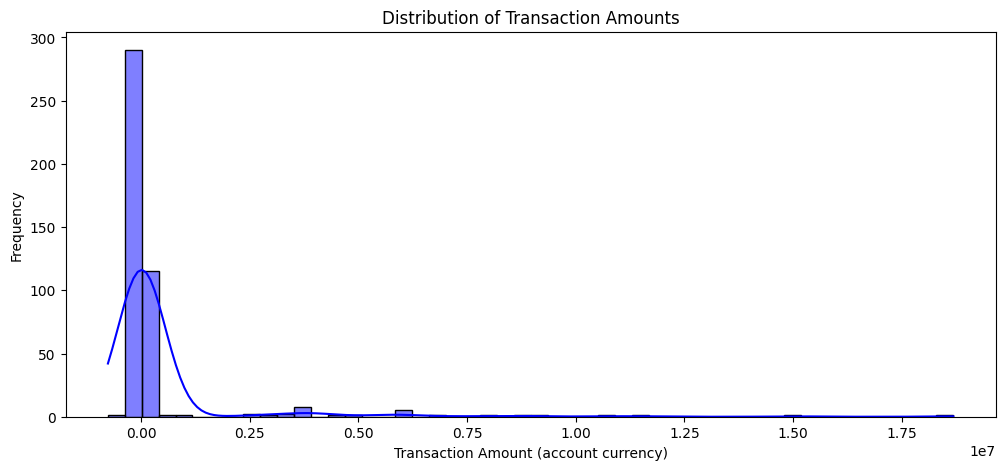

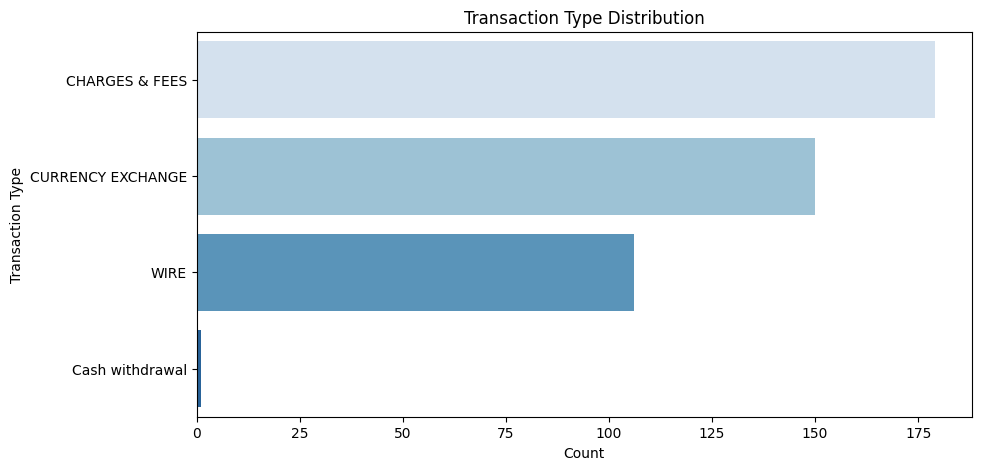

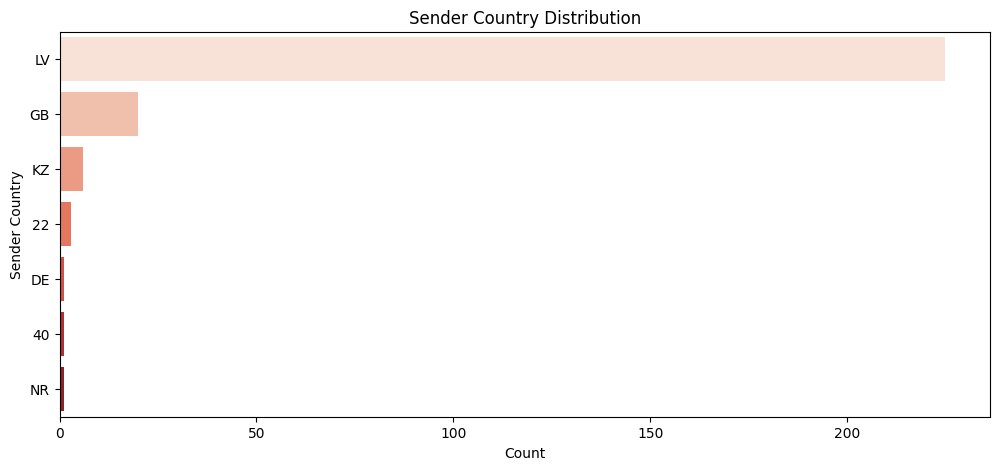

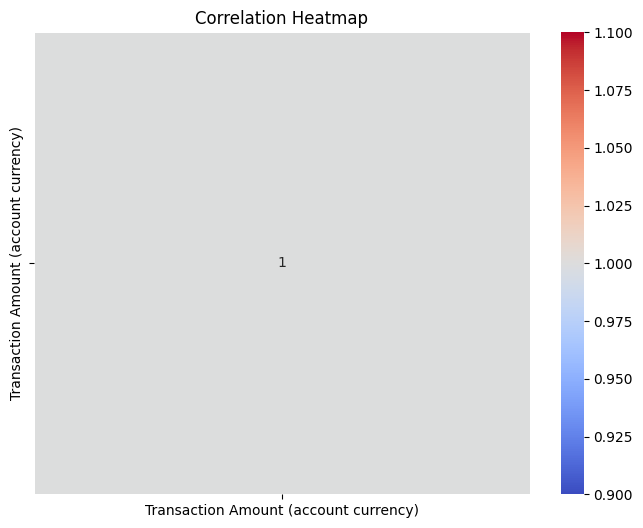

,Transaction Type (C/D),TRX_TYPE_1,Transaction Type,Transaction subtype,Transaction description,Purpose of payment,Bank name,Transaction Date,Transaction Amount (account currency),Currency,Name of beneficiary/originator,Beneficiary/originator account number,TRX_SEN_BANK_COUNTRY
0,De,currency exchange,CURRENCY EXCHANGE,CURRENCY EXCHANGE: intraclient,"currency exchange, No. 881, 7344.00 RUB => 120...",NaN,No Bank Found,2017-01-16,-7344.0,RUB,LEMURS CONTRACTS LP,LV61KKKK8686010354692,LV
1,Cr,currency exchange,CURRENCY EXCHANGE,CURRENCY EXCHANGE: intraclient,"currency exchange, No. 881, 7344.00 RUB => 120...",NaN,No Bank Found,2017-01-16,120.0,USD,LEMURS CONTRACTS LP,LV61KKKK8686010354692,LV
2,De,1556948.BANK Y.CURR.MNTH.FEE.20170131,CHARGES & FEES,CHARGES & FEES,"1556948.BANK Y.CURR.MNTH.FEE.20170131, account...",NaN,BANK Y.CURR.MNTH.FEE.20170131,2017-01-31,-55.0,EUR,NaN,NaN,NaN
3,Cr,intrabank payment,WIRE,WIRE: Intrabank,"intrabank payment, No. 30, LUSIS UNIVERSAL LI...",Titanium dioxide,bank payment,2017-02-02,158400.0,USD,LUSIS UNIVERSAL LIMITED,LV82KKKK8686010404754,LV
4,Cr,incoming payment,WIRE,WIRE: Interbank,"incoming payment, No. IVIH02029900248, OPTIMUS...",PAYMENT FOR THE TITAN DIOXIDE ACCORDING TO PER...,BANKA (RRRRLV2XXXX),2017-02-02,19860.0,USD,OPTIMUS TECHNOLOGY SUPPORT L.P. United Kingdom,LV64RRRR8686618806745,LV


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load real transaction data from Lemurs dataset
lemurs_file = "LEMURS CONTRACTS LP transactions.xlsx"
df_real = pd.read_excel(lemurs_file, sheet_name='Sheet1')

df_real.columns = df_real.columns.str.strip()

# Display dataset summary
summary_stats = {
    "Total Transactions": len(df_real),
    "Unique Transaction Types": df_real["Transaction Type"].nunique(),
    "Unique Currencies": df_real["Currency"].nunique(),
    "Unique Sender Countries": df_real["TRX_SEN_BANK_COUNTRY"].nunique(),
    "Transaction Amount Min": df_real["Transaction Amount (account currency)"].min(),
    "Transaction Amount Max": df_real["Transaction Amount (account currency)"].max(),
    "Transaction Amount Mean": df_real["Transaction Amount (account currency)"].mean(),
    "Transaction Amount Std": df_real["Transaction Amount (account currency)"].std(),
}
print(summary_stats)

# Plot transaction amount distribution
plt.figure(figsize=(12, 5))
sns.histplot(df_real["Transaction Amount (account currency)"], bins=50, kde=True, color='blue')
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount (account currency)")
plt.ylabel("Frequency")
plt.show()

# Plot transaction types count
plt.figure(figsize=(10, 5))
sns.countplot(y=df_real["Transaction Type"], order=df_real["Transaction Type"].value_counts().index, palette="Blues")
plt.title("Transaction Type Distribution")
plt.xlabel("Count")
plt.ylabel("Transaction Type")
plt.show()

# Plot sender country distribution
plt.figure(figsize=(12, 5))
sns.countplot(y=df_real["TRX_SEN_BANK_COUNTRY"], order=df_real["TRX_SEN_BANK_COUNTRY"].value_counts().index, palette="Reds")
plt.title("Sender Country Distribution")
plt.xlabel("Count")
plt.ylabel("Sender Country")
plt.show()

# Correlation matrix of numeric values
plt.figure(figsize=(8, 6))
sns.heatmap(df_real[["Transaction Amount (account currency)"]].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Display first few rows of dataset
df_real.head()

Analysis of Real Data:
1.   Total Transactions: 436
2.   Unique Transaction Types: 4
The dataset contains a limited number of transaction types.
3.   Unique Currencies: 3
The transactions occur in a small number of different currencies.
4.   Unique Sender Countries: 7
The transactions originate from 7 different countries.
5.   Transaction Amount Statistics:

Min: -759,475.2 (Possible refunds or reversals)
Max: 18,686,000.0 (Very large transactions)
Mean: 412,668.88
Standard Deviation: 1,796,482.04 (High variability)

# GAN - The fraud scenarios used in this dataset are:

* Rapid Currency Conversion – Immediate conversion of received funds to another currency.
* Daily/Monthly Turnover Thresholds – Turnover exceeded predefined monthly threshold.
* Circular Money Flow – Funds moving in a circular pattern between related accounts.
* Transit Payments – Funds transferred shortly after receipt.
* Transaction Structuring – Multiple transactions structured to avoid reporting limits.
* High-Risk Country Transactions – Significant transactions with high-risk jurisdictions.

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam

# Seeds
np.random.seed(42)
tf.random.set_seed(42)

# Fraud types
fraud_scenarios = {
    "Rapid Currency Conversion": "Immediate conversion of received funds to another currency.",
    "Daily/Monthly Turnover Thresholds": "Turnover exceeded predefined monthly threshold.",
    "Circular Money Flow": "Funds moving in a circular pattern between related accounts.",
    "Transit Payments": "Funds transferred shortly after receipt.",
    "Transaction Structuring": "Multiple transactions structured to avoid reporting limits.",
    "High-Risk Country Transactions": "Significant transactions with high-risk jurisdictions."
}

# Load data
lemurs_file = "LEMURS CONTRACTS LP transactions.xlsx"
df_lemurs = pd.read_excel(lemurs_file, sheet_name='Sheet1')
df_lemurs.columns = df_lemurs.columns.str.strip()

# Real fields
lemurs_senders = df_lemurs["Name of beneficiary/originator"].dropna().unique()
lemurs_receivers = df_lemurs["Transaction description"].dropna().unique()
lemurs_accounts = df_lemurs["Beneficiary/originator account number"].dropna().unique()
lemurs_transaction_types = df_lemurs["Transaction Type"].dropna()
lemurs_currencies = df_lemurs["Currency"].dropna().unique()
lemurs_sender_countries = df_lemurs["TRX_SEN_BANK_COUNTRY"].dropna().unique()
lemurs_amounts = df_lemurs["Transaction Amount (account currency)"].dropna().values

# Scale amounts
amounts = lemurs_amounts.reshape(-1, 1)
amount_scaler = MinMaxScaler(feature_range=(-1, 1))
amounts_scaled = amount_scaler.fit_transform(amounts)

latent_dim = 16  # latent size

# Discriminator
discriminator = Sequential([
    Dense(32, input_shape=(1,)),
    LeakyReLU(alpha=0.2),
    Dense(32),
    LeakyReLU(alpha=0.2),
    Dense(1, activation="sigmoid")
])
discriminator.compile(optimizer=Adam(0.0002, 0.5), loss="binary_crossentropy")

# Generator
generator = Sequential([
    Dense(32, input_shape=(latent_dim,)),
    LeakyReLU(alpha=0.2),
    Dense(32),
    LeakyReLU(alpha=0.2),
    Dense(1, activation="tanh")
])

# GAN model
discriminator.trainable = False
gan = Sequential([generator, discriminator])
gan.compile(optimizer=Adam(0.0002, 0.5), loss="binary_crossentropy")

# Train GAN
epochs = 2000
batch_size = 64

for epoch in range(epochs):
    # Real
    idx = np.random.randint(0, amounts_scaled.shape[0], batch_size)
    real_samples = amounts_scaled[idx]

    # Fake
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    gen_samples = generator.predict(noise, verbose=0)

    real_y = np.ones((batch_size, 1))
    fake_y = np.zeros((batch_size, 1))

    d_loss_real = discriminator.train_on_batch(real_samples, real_y)
    d_loss_fake = discriminator.train_on_batch(gen_samples, fake_y)

    # Train G
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    valid_y = np.ones((batch_size, 1))
    g_loss = gan.train_on_batch(noise, valid_y)

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1}/{epochs} | d_real: {d_loss_real:.4f}, "
              f"d_fake: {d_loss_fake:.4f}, g: {g_loss:.4f}")

# Sample amount
def sample_transaction_amount():
    noise = np.random.normal(0, 1, (1, latent_dim))
    gen_scaled = generator.predict(noise, verbose=0)
    gen_amount = amount_scaler.inverse_transform(gen_scaled)[0][0]

    noise_add = np.random.normal(loc=0, scale=max(abs(gen_amount) * 0.01, 5))
    final_value = max(-759475.2, min(18686000.0, gen_amount + noise_add))
    return round(float(final_value), 2)

# Tx type probs
tx_type_probs = lemurs_transaction_types.value_counts(normalize=True).to_dict()

# Generate data
num_samples = 10000
synthetic_data = []

for _ in range(num_samples):
    fraud_scenario = np.random.choice(list(fraud_scenarios.keys()))
    txn_type = np.random.choice(list(tx_type_probs.keys()), p=list(tx_type_probs.values()))
    amount = sample_transaction_amount()
    currency = np.random.choice(lemurs_currencies)
    sender_country = np.random.choice(lemurs_sender_countries)
    receiver_country = np.random.choice(lemurs_sender_countries)
    description = fraud_scenario
    sender_name = np.random.choice(lemurs_senders)
    receiver_name = np.random.choice(lemurs_senders)
    sender_account = np.random.choice(lemurs_accounts)
    receiver_account = np.random.choice(lemurs_accounts)
    transaction_frequency = float(np.random.randint(1, 50))
    time_between_transactions = float(np.random.uniform(0.5, 48))
    rolling_avg_amount = float(np.random.uniform(5000, 100000))
    transaction_std_dev = float(np.random.uniform(1000, 50000))
    amount_ratio = float(amount / rolling_avg_amount)
    time_std_dev = float(np.random.uniform(0.1, 24))

    synthetic_data.append([
        fraud_scenario, txn_type, amount, currency, sender_country,
        receiver_country, description, sender_name, receiver_name,
        sender_account, receiver_account, transaction_frequency,
        time_between_transactions, rolling_avg_amount,
        transaction_std_dev, amount_ratio, time_std_dev
    ])

# DataFrame
columns = [
    "Risk Scenario", "Transaction Type", "Amount", "Currency", "Sender Country",
    "Receiver Country", "Transaction Description", "Sender Name", "Receiver Name",
    "Sender Account Number", "Receiver Account Number", "Transaction Frequency",
    "Time Between Transactions", "Rolling Avg Amount", "Transaction Std Dev",
    "Amount Ratio", "Time Std Dev"
]
df_synthetic = pd.DataFrame(synthetic_data, columns=columns)

# Numeric only
numeric_features = [
    "Amount", "Transaction Frequency", "Time Between Transactions",
    "Rolling Avg Amount", "Transaction Std Dev", "Amount Ratio", "Time Std Dev"
]

df_synthetic[numeric_features] = df_synthetic[numeric_features].apply(
    pd.to_numeric, errors='coerce'
)
df_synthetic = df_synthetic.dropna(subset=numeric_features)

# Correlation filter
correlation_matrix = df_synthetic[numeric_features].corr().abs()
print("correlation matrix (|ρ|):")
print(correlation_matrix.round(3))
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
highly_correlated_features = [
    column for column in upper_triangle.columns if any(upper_triangle[column] > 0.95)
]
print("\nАeatures с |ρ| > 0.95 and removed from the set:")
print(highly_correlated_features)
df_synthetic = df_synthetic.drop(columns=highly_correlated_features)

# Scale numeric
numeric_features_final = [c for c in numeric_features if c in df_synthetic.columns]
scaler = MinMaxScaler()
df_synthetic[numeric_features_final] = scaler.fit_transform(
    df_synthetic[numeric_features_final]
)

# Save CSV
output_file = "synthetic_transactions.csv"
df_synthetic.to_csv(output_file, index=False)

df_synthetic.head()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 500/2000 | d_real: 0.7664, d_fake: 0.7663, g: 0.7099
Epoch 1000/2000 | d_real: 0.7688, d_fake: 0.7688, g: 0.7047
Epoch 1500/2000 | d_real: 0.7699, d_fake: 0.7699, g: 0.7023
Epoch 2000/2000 | d_real: 0.7706, d_fake: 0.7706, g: 0.7008
correlation matrix (|ρ|):
                           Amount  Transaction Frequency  \
Amount                      1.000                  0.007   
Transaction Frequency       0.007                  1.000   
Time Between Transactions   0.006                  0.011   
Rolling Avg Amount          0.006                  0.001   
Transaction Std Dev         0.017                  0.008   
Amount Ratio                0.034                  0.000   
Time Std Dev                0.004                  0.006   

                           Time Between Transactions  Rolling Avg Amount  \
Amount                                         0.006               0.006   
Transaction Frequency                          0.011               0.001   
Time Between Transactions 

,Risk Scenario,Transaction Type,Amount,Currency,Sender Country,Receiver Country,Transaction Description,Sender Name,Receiver Name,Sender Account Number,Receiver Account Number,Transaction Frequency,Time Between Transactions,Rolling Avg Amount,Transaction Std Dev,Amount Ratio,Time Std Dev
0,Circular Money Flow,WIRE,0.655675,USD,NR,22,Circular Money Flow,"MAX FAMOUS INTERNATIONAL TRADING CO., LIMITED,...","Arcelor NAVAHO JSC 1, NAVAHO, KARAGANDA AREA, ...",KZ1111111111,LV77 KKKK 8686 0103 7933 3,0.687500,0.773789,0.161231,0.519462,0.211437,0.629298
1,High-Risk Country Transactions,CURRENCY EXCHANGE,0.481766,RUB,NR,LV,High-Risk Country Transactions,LEMURS CONTRACTS LP,"GENIUS AURA LIMITED, TAIWAN",222222222222222,KZ1111111111,0.937500,0.179912,0.116692,0.337821,0.256257,0.293144
2,Transit Payments,CHARGES & FEES,0.547716,USD,22,LV,Transit Payments,TLV NORD PTE. LTD.,"ТОО GK CHIM ALMATY, Kazakhstan",GB00000000,LV95 KKKK 8686 0103 8366 5,0.291667,0.818485,0.287011,0.162639,0.110337,0.964569
3,High-Risk Country Transactions,CURRENCY EXCHANGE,0.510084,RUB,22,NR,High-Risk Country Transactions,Torrvec LIMITED,LUSIS UNIVERSAL LIMITED,NRA150000000,LV67 KKKK 0001 1401 0349 6,0.354167,0.302950,0.233600,0.677435,0.136137,0.304035
4,Daily/Monthly Turnover Thresholds,CHARGES & FEES,0.569338,RUB,LV,40,Daily/Monthly Turnover Thresholds,Torrvec LIMITED,TRADING HOUSE OF VROOM AVTO LLC,LV65 KKKK 8686 0103 8439 9,LV36KKKK8686010386570,0.437500,0.588441,0.654358,0.503331,0.031256,0.939929


# Comparison - Real VS GAN
* Kolmogorov-Smirnov (KS) Test – Checks similarity of transaction amounts.
* Chi-Square Test – Compares categorical distributions (transaction types).
* Data Distribution Analysis – Visualizes distributions with histograms & boxplots.
* PCA (Principal Component Analysis) – Plots real vs. synthetic data in 2D space.

KS Test Statistic: 0.6605504587155964, P-Value: 2.1820182972036132e-178
Chi-Square Test Statistic: 9.582377729524654e-05, P-Value: 0.9999997505311922


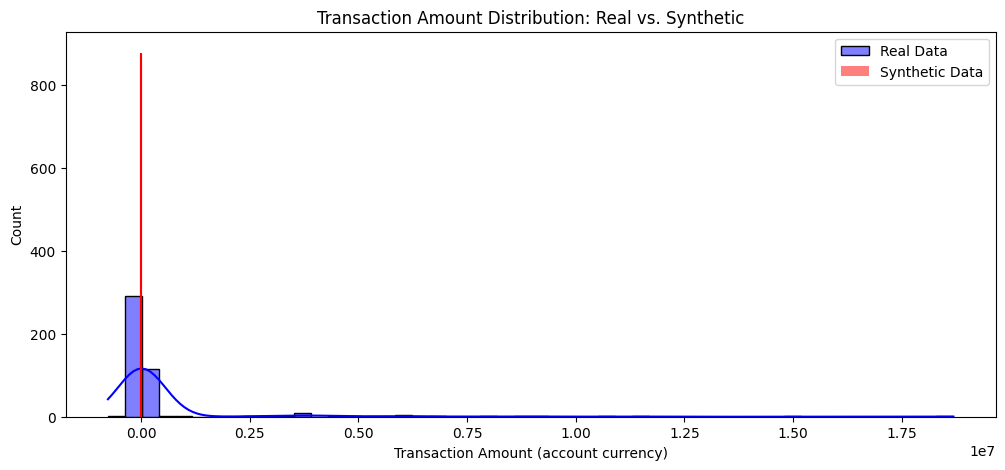

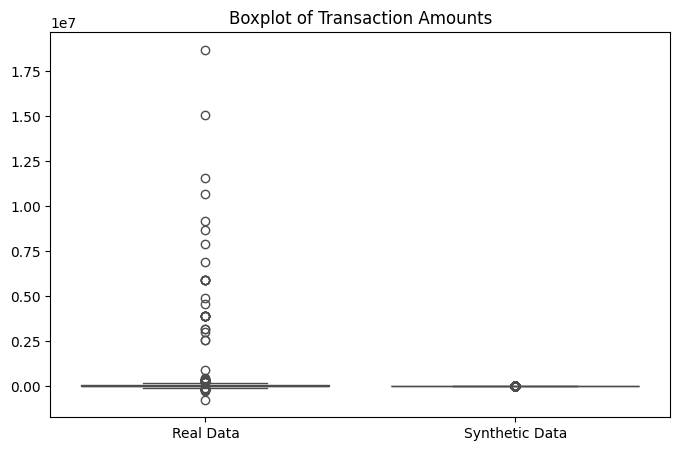

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load real and synthetic data
real_data_file = "LEMURS CONTRACTS LP transactions.xlsx"
synthetic_data_file = "synthetic_transactions.csv"

df_real = pd.read_excel(real_data_file, sheet_name='Sheet1')
df_synthetic = pd.read_csv(synthetic_data_file)

# Standardize column names
df_real.columns = df_real.columns.str.strip()
df_synthetic.columns = df_synthetic.columns.str.strip()

# Select relevant columns
real_amounts = df_real["Transaction Amount (account currency)"].dropna()
synthetic_amounts = df_synthetic["Amount"].dropna()

# 1. Kolmogorov-Smirnov (KS) Test for transaction amounts
ks_stat, ks_p_value = stats.ks_2samp(real_amounts, synthetic_amounts)
print(f"KS Test Statistic: {ks_stat}, P-Value: {ks_p_value}")

# 2. Chi-Square Test for categorical distributions (Transaction Type)
real_types = df_real["Transaction Type"].dropna().value_counts()
synthetic_types = df_synthetic["Transaction Type"].dropna().value_counts()
common_types = real_types.index.intersection(synthetic_types.index)

df_comparison = pd.DataFrame({
    "Real": real_types[common_types],
    "Synthetic": synthetic_types[common_types]
}).fillna(0)

# Normalize frequencies to match sums for chi-square test
df_comparison["Real"] = df_comparison["Real"] / df_comparison["Real"].sum()
df_comparison["Synthetic"] = df_comparison["Synthetic"] / df_comparison["Synthetic"].sum()

chi2_stat, chi2_p_value = stats.chisquare(df_comparison["Synthetic"] * df_comparison["Real"].sum(),
                                          df_comparison["Real"] * df_comparison["Real"].sum())
print(f"Chi-Square Test Statistic: {chi2_stat}, P-Value: {chi2_p_value}")

# 3. Data Distribution Analysis (Histograms & Boxplots)
plt.figure(figsize=(12, 5))
sns.histplot(real_amounts, color='blue', label='Real Data', kde=True, bins=50)
sns.histplot(synthetic_amounts, color='red', label='Synthetic Data', kde=True, bins=50)
plt.legend()
plt.title("Transaction Amount Distribution: Real vs. Synthetic")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=[real_amounts, synthetic_amounts], palette=["blue", "red"])
plt.xticks([0, 1], ["Real Data", "Synthetic Data"])
plt.title("Boxplot of Transaction Amounts")
plt.show()

# 4. PCA Analysis for Real vs. Synthetic Data
numeric_features = ["Amount", "Transaction Frequency", "Time Between Transactions", "Rolling Avg Amount", "Transaction Std Dev", "Amount Ratio", "Time Std Dev"]

# Ensure required numeric columns exist in both datasets
real_numeric_features = [feature for feature in numeric_features if feature in df_real.columns]
synthetic_numeric_features = [feature for feature in numeric_features if feature in df_synthetic.columns]

if len(real_numeric_features) < 2 or len(synthetic_numeric_features) < 2:
    print("Warning: Not enough features for PCA. Skipping PCA analysis.")
else:
    real_pca_data = df_real[real_numeric_features].dropna()
    synthetic_pca_data = df_synthetic[synthetic_numeric_features].dropna()

    # Standardize numeric data before PCA
    scaler = StandardScaler()
    real_pca_data = scaler.fit_transform(real_pca_data)
    synthetic_pca_data = scaler.transform(synthetic_pca_data)

    pca = PCA(n_components=2)
    pca_real = pca.fit_transform(real_pca_data)
    pca_synthetic = pca.transform(synthetic_pca_data)

    plt.figure(figsize=(10, 6))
    plt.scatter(pca_real[:, 0], pca_real[:, 1], alpha=0.5, label="Real Data", color="blue")
    plt.scatter(pca_synthetic[:, 0], pca_synthetic[:, 1], alpha=0.5, label="Synthetic Data", color="red")
    plt.legend()
    plt.title("PCA Analysis of Real vs. Synthetic Data")
    plt.show()

# Decision Tree for Scenario Combinations

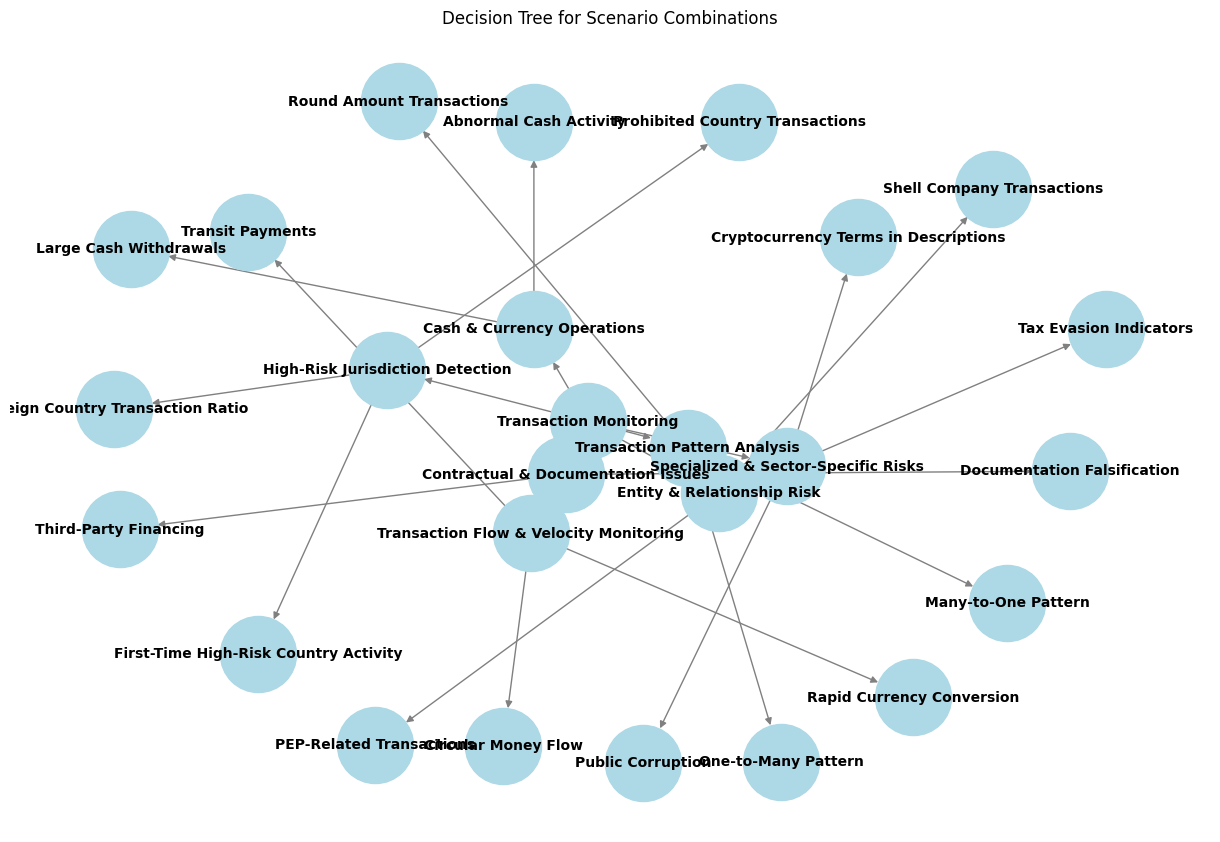

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_decision_tree():
    G = nx.DiGraph()

    # Define nodes
    categories = {
        "Transaction Monitoring": [
            "Transaction Flow & Velocity Monitoring",
            "High-Risk Jurisdiction Detection",
            "Transaction Pattern Analysis",
            "Entity & Relationship Risk",
            "Contractual & Documentation Issues",
            "Cash & Currency Operations",
            "Specialized & Sector-Specific Risks"
        ],
        "Transaction Flow & Velocity Monitoring": [
            "Transit Payments", "Circular Money Flow", "Rapid Currency Conversion"
        ],
        "High-Risk Jurisdiction Detection": [
            "First-Time High-Risk Country Activity", "Prohibited Country Transactions", "Foreign Country Transaction Ratio"
        ],
        "Transaction Pattern Analysis": [
            "One-to-Many Pattern", "Many-to-One Pattern", "Round Amount Transactions"
        ],
        "Entity & Relationship Risk": [
            "Shell Company Transactions", "PEP-Related Transactions"
        ],
        "Contractual & Documentation Issues": [
            "Documentation Falsification", "Third-Party Financing"
        ],
        "Cash & Currency Operations": [
            "Large Cash Withdrawals", "Abnormal Cash Activity"
        ],
        "Specialized & Sector-Specific Risks": [
            "Cryptocurrency Terms in Descriptions", "Public Corruption", "Tax Evasion Indicators"
        ]
    }

    # Add edges
    for parent, children in categories.items():
        for child in children:
            G.add_edge(parent, child)

    # Draw the graph
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=0.7, seed=42)
    nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", edge_color="gray", font_size=10, font_weight="bold")
    plt.title("Decision Tree for Scenario Combinations")
    plt.show()

# Call function to display the tree
draw_decision_tree()
